In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [3]:
df = pd.read_csv("csv//processed_data.csv")

In [4]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
def confusion_matrix(y_test, y_pred, model_name):
    cm = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        
    )
    cm.ax_.set_title(f"Confusion Matrix for {model_name}")
    return cm

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
logi=LogisticRegression()

logi.fit(X_train_scaled,y_train)

pred_logi=logi.predict(X_test_scaled)

In [9]:
result=[]
def eval(model_name, y_test, predi):

    print("Accuracy :", accuracy_score(y_test, predi))
    print("Precision:", precision_score(y_test, predi))
    print("Recall   :", recall_score(y_test, predi))
    print("F1 Score :", f1_score(y_test, predi))
    print("ROC AUC  :", roc_auc_score(y_test, predi))
    result.append({
    "Model": model_name,
    "Accuracy": accuracy_score(y_test, predi),
    "Precision": precision_score(y_test, predi),
    "Recall": recall_score(y_test, predi),
    "F1 Score": f1_score(y_test, predi),
    "ROC AUC": roc_auc_score(y_test, predi)
    })

Accuracy : 0.801277501774308
Precision: 0.6566666666666666
Recall   : 0.5267379679144385
F1 Score : 0.5845697329376854
ROC AUC  : 0.713610529850939


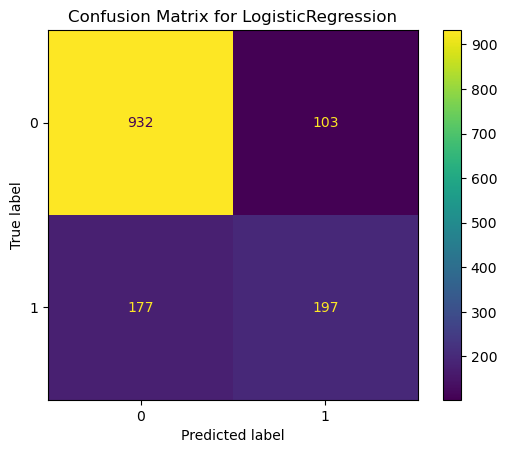

In [10]:
eval("LogisticRegression", y_test, pred_logi)
confusion_matrix(y_test, pred_logi, "LogisticRegression")

In [11]:
deci_tree=DecisionTreeClassifier()

deci_tree.fit(X_train,y_train)

pred_deci=deci_tree.predict(X_test)

Accuracy : 0.7374024130589071
Precision: 0.5057142857142857
Recall   : 0.4732620320855615
F1 Score : 0.4889502762430939
ROC AUC  : 0.6530561368157276


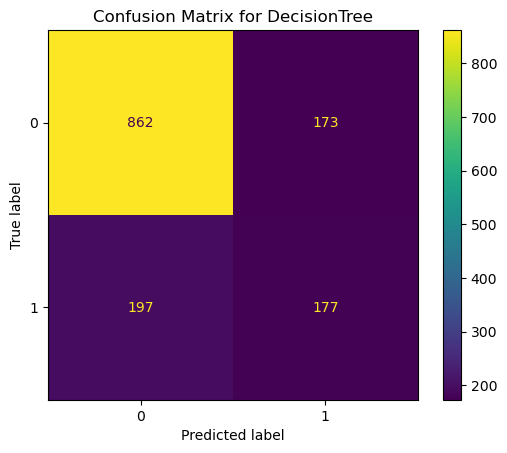

In [12]:
eval("DecisionTree", y_test, pred_deci)
confusion_matrix(y_test, pred_deci, "DecisionTree") 

In [13]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

Accuracy : 0.7920511000709723
Precision: 0.6372881355932203
Recall   : 0.5026737967914439
F1 Score : 0.5620328849028401
ROC AUC  : 0.6996460771396833


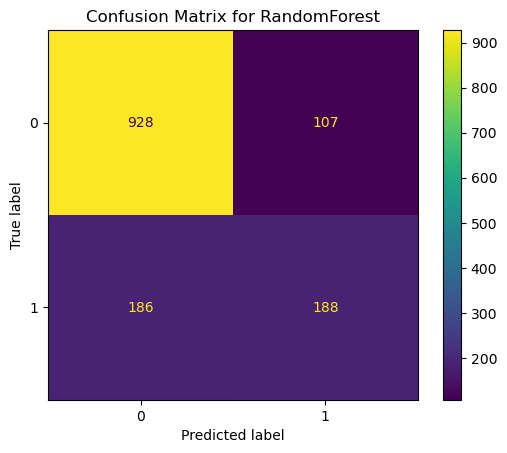

In [14]:
eval("RandomForest", y_test, pred_rf)
confusion_matrix(y_test, pred_rf, "RandomForest")

In [15]:
knn=KNeighborsClassifier()

knn.fit(X_train_scaled,y_train)

pred_knn=knn.predict(X_test_scaled)

Accuracy : 0.7480482611781405
Precision: 0.5269121813031161
Recall   : 0.49732620320855614
F1 Score : 0.5116918844566712
ROC AUC  : 0.6679867731018626


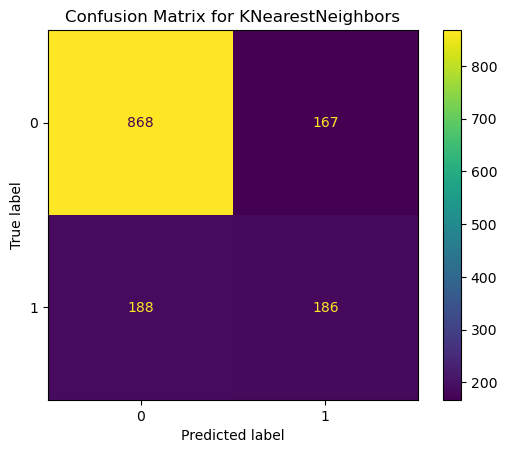

In [16]:
eval("KNearestNeighbors", y_test, pred_knn)
confusion_matrix(y_test, pred_knn, "KNearestNeighbors")

In [17]:
svm = SVC(probability=True, random_state=42)

svm.fit(X_train_scaled, y_train)

pred_svm= svm.predict(X_test_scaled)

/home/sahil/miniconda3/envs/ds/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy : 0.7955997161107168
Precision: 0.6535714285714286
Recall   : 0.4893048128342246
F1 Score : 0.5596330275229358
ROC AUC  : 0.6977925030354698


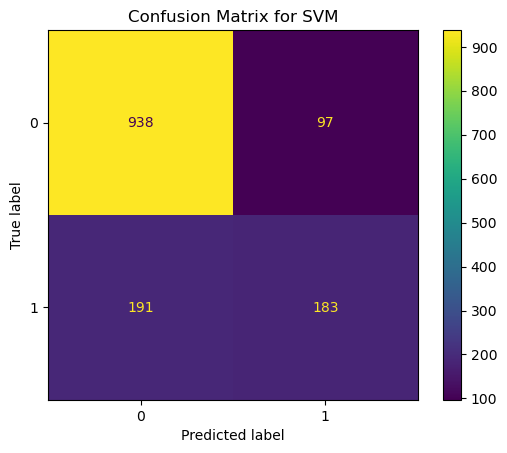

In [18]:
eval("SVM", y_test, pred_svm)
confusion_matrix(y_test, pred_svm, "SVM")

In [19]:
nb = GaussianNB()

nb.fit(X_train, y_train)

pred_nb= nb.predict(X_test)

Accuracy : 0.6763662171753017
Precision: 0.44273743016759776
Recall   : 0.8475935828877005
F1 Score : 0.581651376146789
ROC AUC  : 0.7310431682554444


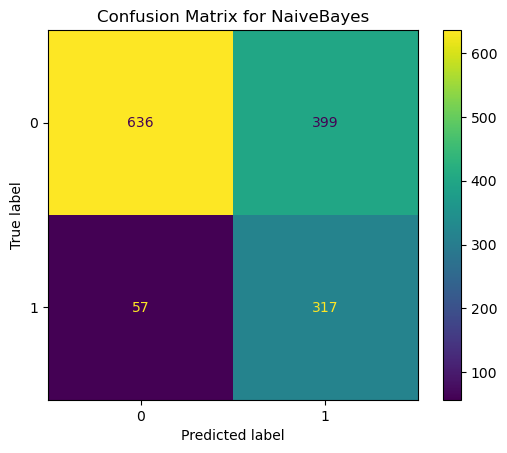

In [20]:
eval("NaiveBayes", y_test, pred_nb)
confusion_matrix(y_test, pred_nb, "NaiveBayes")

In [21]:
comparison=pd.DataFrame(result)

In [22]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.801278,0.656667,0.526738,0.584570,0.713611
1,DecisionTree,0.737402,0.505714,0.473262,0.488950,0.653056
2,RandomForest,0.792051,0.637288,0.502674,0.562033,0.699646
3,KNearestNeighbors,0.748048,0.526912,0.497326,0.511692,0.667987
4,SVM,0.795600,0.653571,0.489305,0.559633,0.697793
5,NaiveBayes,0.676366,0.442737,0.847594,0.581651,0.731043


In [23]:
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

In [24]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.801278,0.656667,0.526738,0.584570,0.713611
4,SVM,0.795600,0.653571,0.489305,0.559633,0.697793
2,RandomForest,0.792051,0.637288,0.502674,0.562033,0.699646
3,KNearestNeighbors,0.748048,0.526912,0.497326,0.511692,0.667987
1,DecisionTree,0.737402,0.505714,0.473262,0.488950,0.653056
5,NaiveBayes,0.676366,0.442737,0.847594,0.581651,0.731043


In [25]:
comparison.to_csv("csv//comparisons//comparisons.csv")